Equazione della parabola (calcolata escludendo y=0): y = 0.120x^2 + -3.040x + 18.698

Valori previsti dal modello:
x =  0 -> y = 18.70
x =  1 -> y = 15.78
x =  2 -> y = 13.10
x =  3 -> y = 10.66
x =  4 -> y = 8.47
x =  5 -> y = 6.51
x =  6 -> y = 4.79
x =  7 -> y = 3.32
x =  8 -> y = 2.09
x =  9 -> y = 1.09
x = 10 -> y = 0.34
x = 11 -> y = -0.17
x = 12 -> y = -0.44
x = 13 -> y = -0.47
x = 14 -> y = -0.26
x = 15 -> y = 0.19
x = 16 -> y = 0.88
x = 17 -> y = 1.81
x = 18 -> y = 2.99
x = 19 -> y = 4.40
x = 20 -> y = 6.06


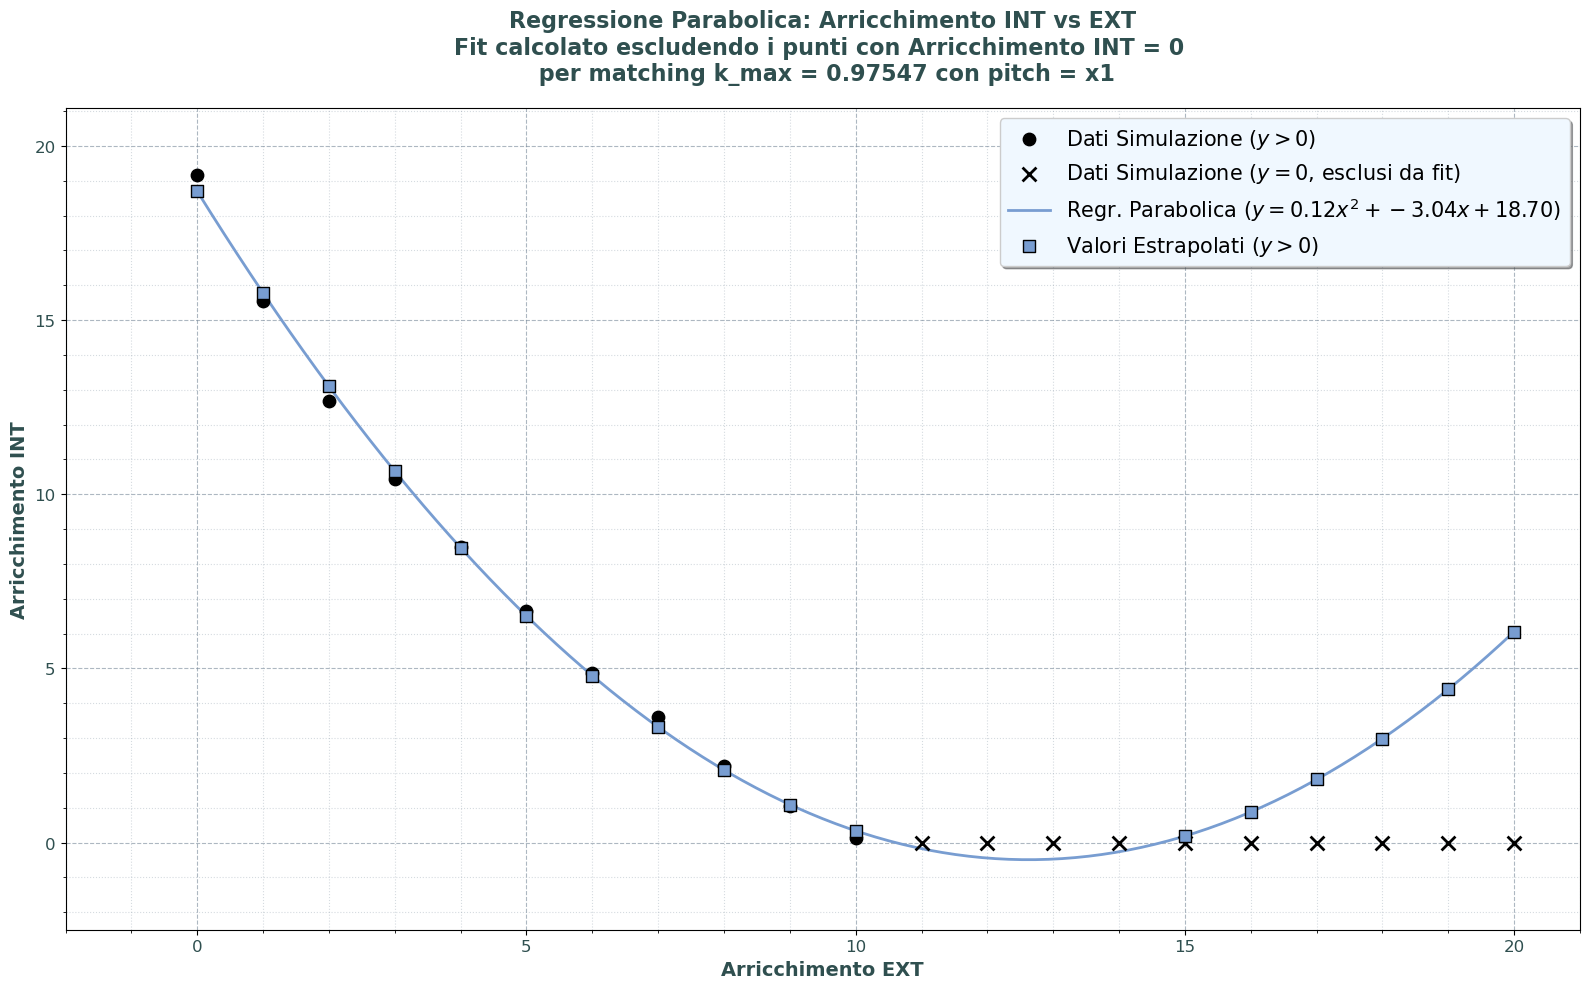

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analizza_e_plotta(file_path):
    """
    Legge i dati di simulazione, esegue regressione parabolica ESCLUDENDO i punti con y=0,
    e genera il plot differenziando i marcatori per y=0.
    """
    # Definizione manuale delle colonne
    nomi_colonne = [
        'Pres', 'moltiplicatore', 'PERC_water', 'Arricch_MAX',
        'Arricch_min', 'T_WATER', 'T_FUEL', 'K_max', 'std_k_max',
        'K_auto', 'std_k_auto', 'Compatibilità'
    ]
    
    # Lettura del file
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=3, names=nomi_colonne, engine='python')
    
    # Estrazione array completi per la visualizzazione
    x_tutti = df['Arricch_min'].values
    y_tutti = df['Arricch_MAX'].values

    # --- MODIFICA 1: Filtro dei dati per la regressione ---
    # Creiamo maschere booleane per separare i dati validi (y > 0) da quelli nulli (y = 0)
    maschera_validi = y_tutti > 0
    maschera_zeri = y_tutti == 0

    x_validi = x_tutti[maschera_validi]
    y_validi = y_tutti[maschera_validi]

    x_zeri = x_tutti[maschera_zeri]
    y_zeri = y_tutti[maschera_zeri]

    # --- MODIFICA 2: Regressione solo sui dati validi ---
    # Calcolo regressione parabolica (polinomio di grado 2) usando SOLO x_validi, y_validi
    a, b, c = np.polyfit(x_validi, y_validi, 2)

    # Vettori per l'estrapolazione del modello (x da 1 a 20)
    x_pred = np.arange(0, 21)
    y_pred = a * x_pred**2 + b * x_pred + c

    # Output analitico a terminale (ora basato sul nuovo modello)
    print(f"Equazione della parabola (calcolata escludendo y=0): y = {a:.3f}x^2 + {b:.3f}x + {c:.3f}\n")
    print("Valori previsti dal modello:")
    for x, y in zip(x_pred, y_pred):
        y_visualizzato = y
        print(f"x = {x:2d} -> y = {y_visualizzato:.2f}")

    # Configurazione della Figura
    fig, ax = plt.subplots(figsize=(16, 10))

    # --- MODIFICA 3: Plot differenziato dei dati di simulazione ---
    # 3a. Plot dei dati validi (pallini neri)
    ax.scatter(x_validi, y_validi, color='#000000', s=80, zorder=5, label='Dati Simulazione ($y>0$)')
    
    # 3b. Plot dei dati con y=0 (X nera)
    ax.scatter(x_zeri, y_zeri, color='#000000', marker='x', s=100, linewidth=2, zorder=5, label='Dati Simulazione ($y=0$, esclusi da fit)')

    # Plot della curva di regressione
    x_full = np.linspace(0, 20, 100) # Usiamo più punti per una curva morbida
    y_full = a * x_full**2 + b * x_full + c
    ax.plot(x_full, y_full, color='#789DD1', linestyle='-', linewidth=2, zorder=4, 
            label=f'Regr. Parabolica ($y={a:.2f}x^2+{b:.2f}x+{c:.2f}$)')

    # --- MODIFICA 4: Plot differenziato dei valori estrapolati ---
    # Maschere per i valori previsti
    maschera_pred_validi = y_pred > 0
    maschera_pred_zeri = y_pred <= 0 # Consideriamo zeri anche i valori leggermente negativi del modello

    # 4a. Plot dei valori previsti validi (quadrato azzurro)
    ax.scatter(x_pred[maschera_pred_validi], y_pred[maschera_pred_validi], 
               color='#789DD1', marker='s', s=80, zorder=6, edgecolor='#000000', label='Valori Estrapolati ($y>0$)')

    # Formattazione Titolo e Assi
    ax.set_title('MAPPA DI STABILITA' \n Regressione Parabolica: Arricchimento INT vs EXT\nFit calcolato escludendo i punti con Arricchimento INT = 0 \n per matching k_max = 0.97547 con pitch = x1', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento EXT', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento INT', fontsize=14, fontweight='bold', color='#2F4F4F')

    # Limiti assi per coerenza
    ax.set_xlim(-2, 21)
    ax.set_ylim(-2.5, max(y_tutti.max(), y_pred.max()) * 1.1)

    # Formattazione Tick
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')

    # Setup della griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Setup Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=15, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.savefig('regressione_parabolica_filtrata.png', dpi=300)
    plt.show()

    return a, b, c

a, b, c = analizza_e_plotta('../result_final.txt')


### --- Analisi Rette --- ###

Retta 0 [P_i(1, 18.70) -> P_f(11, 0.00)]: Media = 9.349

Retta 1 [P_i(1, 15.78) -> P_f(11, 1.00)]: Media = 8.389

Retta 2 [P_i(1, 13.10) -> P_f(11, 2.00)]: Media = 7.550

Retta 3 [P_i(1, 10.66) -> P_f(11, 3.00)]: Media = 6.831

Retta 4 [P_i(1, 8.47) -> P_f(11, 4.00)]: Media = 6.233

Retta 5 [P_i(1, 6.51) -> P_f(11, 5.00)]: Media = 5.755

Retta 6 [P_i(1, 4.79) -> P_f(11, 6.00)]: Media = 5.397

Retta 7 [P_i(1, 3.32) -> P_f(11, 7.00)]: Media = 5.160

Retta 8 [P_i(1, 2.09) -> P_f(11, 8.00)]: Media = 5.043

Retta 9 [P_i(1, 1.09) -> P_f(11, 9.00)]: Media = 5.046

Retta 10 [P_i(1, 0.34) -> P_f(11, 10.00)]: Media = 5.170



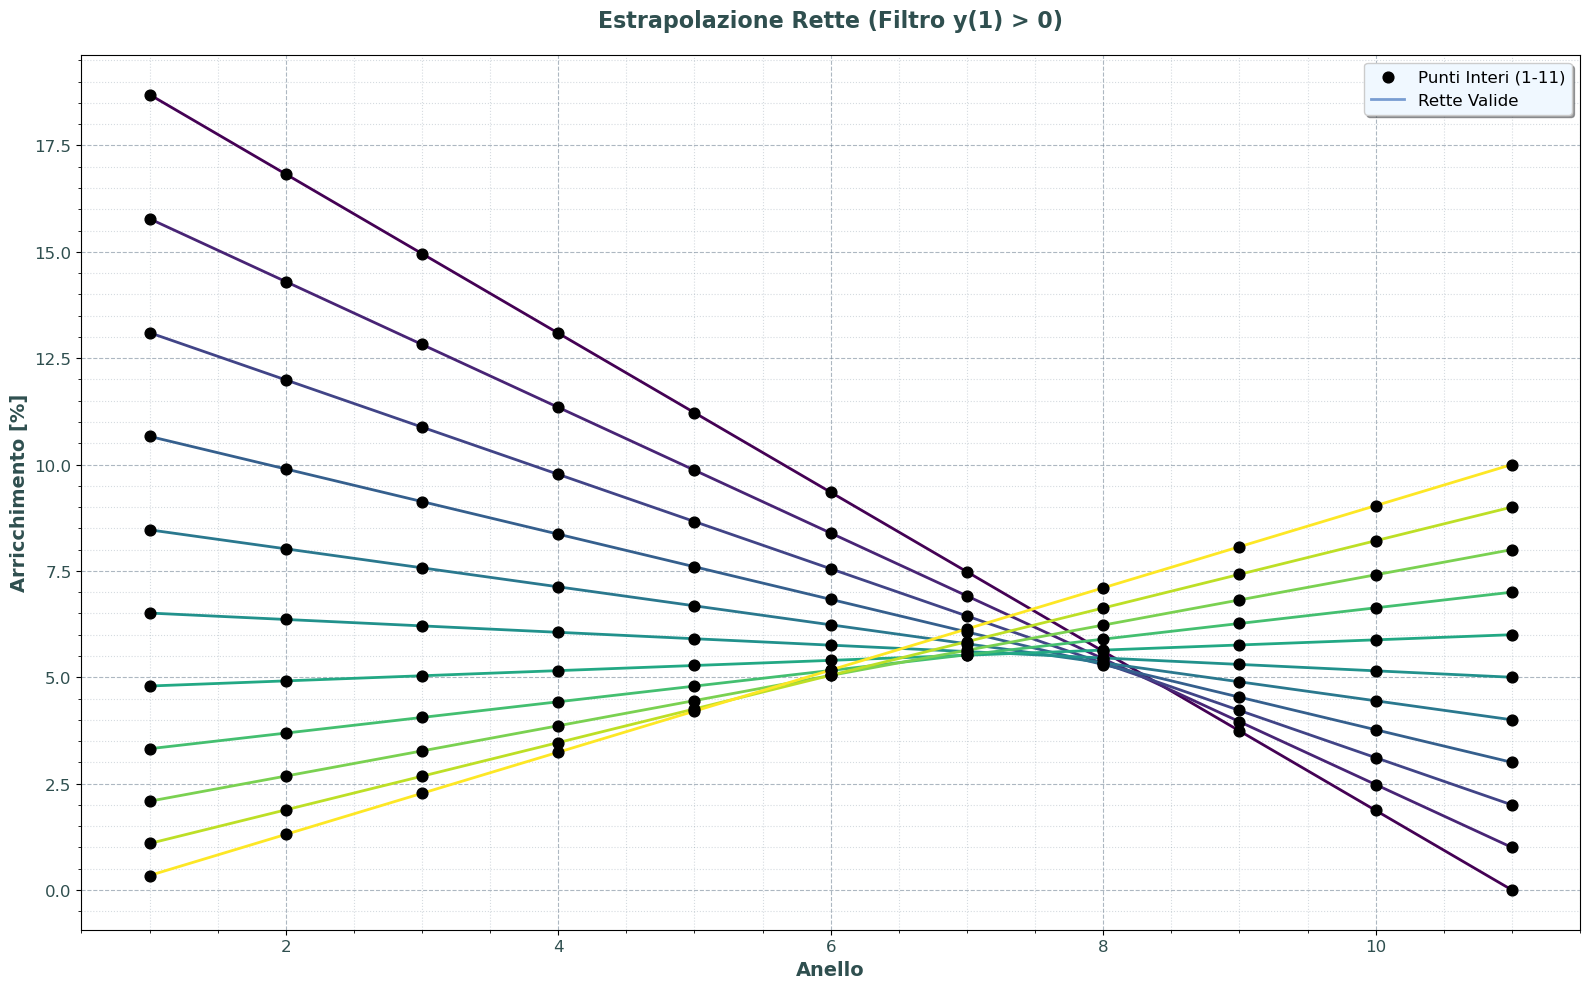

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_rette_filtrate(x_pred, y_pred):
    """
    Traccia rette da (1, y_pred) a (11, x_pred) escludendo quelle 
    con arricchimento iniziale (Anello 1) pari a zero.
    """
    print("### --- Analisi Rette --- ###\n")
    
    fig, ax = plt.subplots(figsize=(16, 10))
    media_vect = []
    x_discrete = np.arange(1, 12)
    
    # Colormap per le rette valide
    colors = cm.viridis(np.linspace(0, 1, len(x_pred)))
    
    for i, (x_p, y_p) in enumerate(zip(x_pred, y_pred)):
        y_start = y_p
        y_end = x_p
        
        # FILTRO: Se l'arricchimento all'anello 1 è 0, salta questa retta
        if y_start == 0:
            continue
            
        # Calcolo coefficienti retta: y = m*x + q
        m = (y_end - y_start) / 10.0
        q = y_start - m * 1.0
        
        # Valutazione sui punti discreti 1-11
        y_discrete = m * x_discrete + q
        media_y = np.mean(y_discrete)
        
        print(f"Retta {i} [P_i(1, {y_start:.2f}) -> P_f(11, {y_end:.2f})]: Media = {media_y:.3f}\n")
        media_vect.append(media_y)
        
        # Plot della retta e dei punti
        ax.plot(x_discrete, y_discrete, color=colors[i], linestyle='-', linewidth=2, zorder=4)
        ax.scatter(x_discrete, y_discrete, color='#000000', s=60, zorder=5)

    # Formattazione grafica standard richiesto
    ax.set_title('Estrapolazione Rette (Filtro y(1) > 0)', fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Anello', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.scatter([], [], color='#000000', s=60, label='Punti Interi (1-11)')
    ax.plot([], [], color='#789DD1', linestyle='-', linewidth=2, label='Rette Valide')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.show()
    
    return np.array(media_vect)

# Definizione dei dati basata sul tuo file analisi.ipynb
x_pred = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_pred = a * x_pred**2 + b * x_pred + c

res = plot_rette_filtrate(x_pred, y_pred)

In [ ]:
import openmc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import os
from scipy.interpolate import make_interp_spline

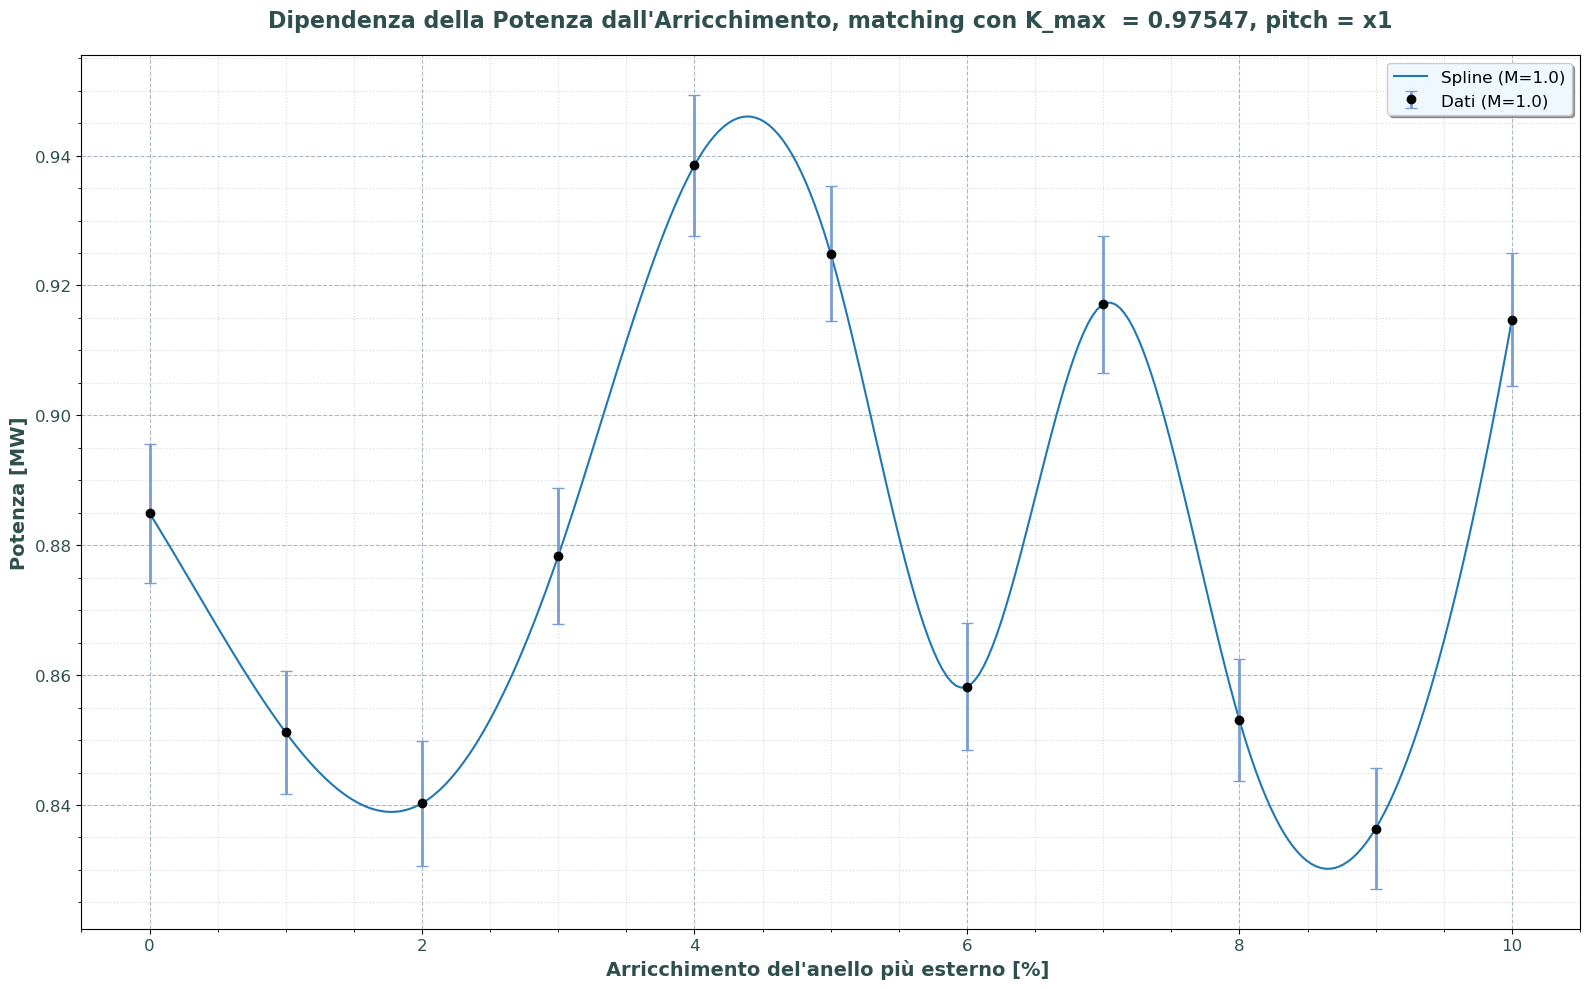

In [ ]:
E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5, estrae media e deviazione standard delle fissioni, calcola potenza e incertezza."""
    file_list = glob.glob("../fixed/statepoints/statepoint_arr_ext_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    pattern = re.compile(r"statepoint_arr_ext_(\d+)_pitch_([\d\.]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        moltiplicatore = float(match.group(2))
        arricchimento = float(match.group(1)) 
        
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0] # Estrazione errore statistico
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza e Incertezza [MW]
        potenza_MW = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        errore_MW = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        dati.append({
            'Arricchimento': arricchimento,
            'Moltiplicatore': moltiplicatore,
            'Potenza_MW': potenza_MW,
            'Errore_MW': errore_MW
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Genera plot a dispersione con barre di errore e interpolazione spline cubica."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    moltiplicatori = df['Moltiplicatore'].unique()
    
    for m in moltiplicatori:
        df_m = df[df['Moltiplicatore'] == m].sort_values(by='Arricchimento')
        
        x = df_m['Arricchimento'].values
        y = df_m['Potenza_MW'].values
        y_err = df_m['Errore_MW'].values
        
        # Plot dei punti centrali con barre di errore (styling rigoroso)
        ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                    elinewidth=2, capsize=4, zorder=5, label=f'Dati (M={m})')
        
        # Interpolazione morbida
        if len(x) >= 3:
            x_smooth = np.linspace(x.min(), x.max(), 300)
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            ax.plot(x_smooth, y_smooth, zorder=4, label=f'Spline (M={m})')
        else:
            ax.plot(x, y, zorder=4, label=f'Line (M={m})')
            
    # Formattazione
    ax.set_title('Dipendenza della Potenza dall\'Arricchimento, matching con K_max  = 0.97547, pitch = x1', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento del\'anello più esterno [%] ', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, 
              fontsize=12, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.savefig('scatter_potenza_errore.png', dpi=300)
    plt.show()

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)